# 🧹 Preprocessing Review — Honest Kartu Kredit

---

## 🎯 Tujuan

Notebook ini mengimplementasikan pipeline *text preprocessing* lengkap untuk menyiapkan data ulasan sebelum analisis sentimen. Pendekatan yang digunakan adalah **data-driven**: EDA dilakukan terlebih dahulu untuk memahami karakteristik teks, baru kemudian langkah pembersihan dirancang berdasarkan temuan aktual dari data tersebut.

---

## 📋 Pipeline Overview

| # | Langkah | Input | Output |
|:--|:--------|:------|:-------|
| 1 | **Load Data** | CSV mentah | `df` |
| 2 | **Lowercasing** | `content` | `text_lower` |
| 3 | **Punctuation & Digit Removal** | `text_lower` | `text_clean` |
| 4 | **Expand Contractions** | `text_clean` | `text_expanded` |
| 5 | **Tokenization** | `text_expanded` | `tokens_raw` |
| 6 | **EDA — Top 200 Kata RAW** | `tokens_raw` | *(observasi)* |
| 7 | **Normalisasi Slang** | `tokens_raw` | `tokens_normalized` |
| 8 | **Stopword Removal (NLTK + Whitelist)** | `tokens_normalized` | `tokens_no_sw` |
| 9 | **Stemming (Sastrawi)** | `tokens_no_sw` | `tokens_stemmed` |
| 10 | **EDA — Top 200 After Cleaning** | `tokens_stemmed` | *(observasi)* |
| 11 | **Custom Stopwords** | `tokens_stemmed` | `tokens_final` |
| 12 | **Rare Words Removal** | `tokens_final` | `tokens_final` |
| 13 | **Ekspor** | `tokens_final` | `cleandata.csv` |

---

## 🛠️ Tools & Libraries

| Library | Fungsi |
|:--------|:-------|
| `pandas`, `numpy` | Manipulasi dan analisis data tabular |
| `re`, `string` | Regex dan pembersihan teks berbasis pola |
| `nltk` | Stopword list Bahasa Indonesia (757 kata) |
| `contractions` | Ekspansi kontraksi bahasa Inggris dalam teks |
| `Sastrawi` | Stemmer morfologi Bahasa Indonesia (rule-based) |
| `matplotlib`, `wordcloud` | Visualisasi distribusi kata dan rating |

---

## 📦 Install & Import Libraries

> **Catatan:** Jalankan cell instalasi ini sekali saat pertama kali menggunakan environment baru.  
> `Sastrawi` adalah library kunci yang tidak tersedia secara default — stemmer ini dirancang khusus untuk morfologi Bahasa Indonesia.

In [95]:
# Install jika belum ada
%pip install sastrawi nltk contractions pandas numpy matplotlib wordcloud -q

Note: you may need to restart the kernel to use updated packages.


In [96]:
import pandas as pd
import numpy as np
import re
import string
import nltk
import contractions
from collections import Counter
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.corpus import stopwords

print("✅ Libraries loaded")

✅ Libraries loaded


---
## 📂 Step 1 — Load Data Mentah

Memuat dataset ulasan yang sudah difilter hanya untuk bahasa Indonesia (hasil dari notebook scraping).  
Kolom utama yang digunakan: `content` (teks ulasan) dan `score` (rating 1–5 bintang).

In [97]:
df = pd.read_csv('../Week 2/df_honest_reviews_id.csv')
print(f"📊 Shape: {df.shape}")
print(f"\n👁️ Preview 3 baris pertama:")
df[['userName', 'content', 'score']].head(3)

📊 Shape: (39324, 12)

👁️ Preview 3 baris pertama:


,userName,content,score
0,Pengguna Google,ini adalah pertama kali saya menggunakan kartu...,5
1,Pengguna Google,"pengajuan berhasil, pelayanan utk CS atas nama...",5
2,Pengguna Google,Pengajuan cepat dan aman..,5


---
## 🔡 Step 2 — Lowercasing (Case Folding)

Mengubah seluruh teks menjadi huruf kecil agar kata yang sama tidak dianggap berbeda akibat perbedaan kapitalisasi, misalnya `"Bagus"` dan `"bagus"` diperlakukan identik.  
Ini adalah langkah normalisasi dasar yang wajib dilakukan sebelum proses teks lebih lanjut.

In [98]:
df['text_lower'] = df['content'].astype(str).str.lower()

# Hitung review yang mengandung huruf kapital
changed_lower = df[df['content'].astype(str) != df['text_lower']]
print(f'📊 Review mengandung huruf kapital : {len(changed_lower):,} dari {len(df):,}')

# Tampilkan contoh yang berubah (ada uppercase → lowercase)
pd.set_option('display.max_colwidth', None)
print(f"\n👁️ Preview 5 baris:")
display(changed_lower[['content', 'text_lower']].head(5))

📊 Review mengandung huruf kapital : 32,006 dari 39,324

👁️ Preview 5 baris:


,content,text_lower
1,"pengajuan berhasil, pelayanan utk CS atas nama Rio sangat sopan dan penjelasan sangat terperinci, terima kasih Honest","pengajuan berhasil, pelayanan utk cs atas nama rio sangat sopan dan penjelasan sangat terperinci, terima kasih honest"
2,Pengajuan cepat dan aman..,pengajuan cepat dan aman..
3,cs Ridwan terbaik,cs ridwan terbaik
6,ok mantep gampang aktifnya dan costemernya mas Fariz ramah dan enak di ajak ngobrol,ok mantep gampang aktifnya dan costemernya mas fariz ramah dan enak di ajak ngobrol
7,Alhamdulillah pelayanan mba azmi cukup memberi infonya semoga bisa cepat naik limitku,alhamdulillah pelayanan mba azmi cukup memberi infonya semoga bisa cepat naik limitku


---
## 🧹 Step 3 — Punctuation & Digit Removal

Menghapus karakter yang tidak membawa makna leksikal:
- **Tanda baca** (`!`, `?`, `.`, `,`, dll.) → diganti spasi agar kata tidak tergabung
- **Angka** (`1`, `2024`, dll.) → dihapus

> **Catatan:** Emoji pictorial (😀, 👍, dll.) sudah ditangani di tahap filter bahasa sebelumnya, sehingga tidak perlu penanganan khusus di sini.

In [99]:
def remove_punctuation(text):
    # Hapus tanda baca dan karakter non-alfanumerik (selain spasi)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\d+', '', text)      # hapus angka
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['text_clean'] = df['text_lower'].apply(remove_punctuation)

# Hitung review yang mengandung tanda baca / angka
changed_punct = df[df['text_lower'] != df['text_clean']]
print(f'📊 Review mengandung tanda baca/angka : {len(changed_punct):,} dari {len(df):,}')

# Tampilkan contoh yang berubah
pd.set_option('display.max_colwidth', None)
print(f"\n👁️ Preview 5 baris:")
display(changed_punct[['text_lower', 'text_clean']].head(5))

📊 Review mengandung tanda baca/angka : 26,058 dari 39,324

👁️ Preview 5 baris:


,text_lower,text_clean
0,ini adalah pertama kali saya menggunakan kartu kredit. yang katanya cocok buat anak muda. nanti saya update pengalaman saya setelah pakai kartu ini. terimakasih buat kak rima yang udah membimbing dengan sangat baik,ini adalah pertama kali saya menggunakan kartu kredit yang katanya cocok buat anak muda nanti saya update pengalaman saya setelah pakai kartu ini terimakasih buat kak rima yang udah membimbing dengan sangat baik
1,"pengajuan berhasil, pelayanan utk cs atas nama rio sangat sopan dan penjelasan sangat terperinci, terima kasih honest",pengajuan berhasil pelayanan utk cs atas nama rio sangat sopan dan penjelasan sangat terperinci terima kasih honest
2,pengajuan cepat dan aman..,pengajuan cepat dan aman
5,trimakasih mba ulfa atas panduan nya sangat demengerti...dan trimakasih kepada aplikasi honest pengajuan saya di setujui...,trimakasih mba ulfa atas panduan nya sangat demengerti dan trimakasih kepada aplikasi honest pengajuan saya di setujui
8,kartu kridit apa2an 😁😁😁 isi saldo dulu baru bisa dipake 🤣🤣 kecuali tipuan,kartu kridit apaan isi saldo dulu baru bisa dipake kecuali tipuan


---
## 📝 Step 4 — Expand Contractions

Memperluas kontraksi bahasa Inggris yang sering muncul dalam ulasan karena pengguna mencampur bahasa Inggris-Indonesia (*code-switching*), misalnya:
- `btw` → `by the way`
- `thx` → `thanks`
- `u` → `you`

> **Catatan:** Langkah ini dilakukan *sebelum* normalisasi slang Indonesia di Step 7 agar tidak terjadi konflik pemetaan.

In [100]:
def expand_text(text):
    try:
        return contractions.fix(text)
    except:
        return text

df['text_expanded'] = df['text_clean'].apply(expand_text)
changed = df[df['text_clean'] != df['text_expanded']]
print(f'📊 Review berubah setelah expand contractions : {len(changed):,} dari {len(df):,}')

# Tampilkan contoh yang benar-benar berubah
pd.set_option('display.max_colwidth', None)
print(f"\n👁️ Preview 5 baris:")
display(changed[['text_clean', 'text_expanded']].head(5))

📊 Review berubah setelah expand contractions : 662 dari 39,324

👁️ Preview 5 baris:


,text_clean,text_expanded
102,the best banget sih ini btw makasih juga buat cs nya mas aang yang sudah membantu verifikasi dan menjelaskan dengan detail dan jelas,the best banget sih ini by the way makasih juga buat cs nya mas aang yang sudah membantu verifikasi dan menjelaskan dengan detail dan jelas
243,pak lois penjelasan nya detail masukan saja untuk sekelas cc untuk keamanan nya tolong di tingkatkan seperting m bangking karna untuk saat ini keamanan hanya sebatas no otp dari whatsapp yang dimana rentan untuk keamanan nya dan untuk fitur masih banyak yang harus di perbanyak lagi sejauh ini blm bisa mengajukan keluhan karna pengguna baru thx,pak lois penjelasan nya detail masukan saja untuk sekelas cc untuk keamanan nya tolong di tingkatkan seperting m bangking karna untuk saat ini keamanan hanya sebatas no otp dari whatsapp yang dimana rentan untuk keamanan nya dan untuk fitur masih banyak yang harus di perbanyak lagi sejauh ini blm bisa mengajukan keluhan karna pengguna baru thanks
273,matappp poolll buat honest aplikasi nya mudah digunakan juga ringan gak bikin hp lemot saat melakukan welcome call cs nya baik sopan dan ramah poko nya d best u pak rio cara penyampaian nya singkat jelas padat,matappp poolll buat honest aplikasi nya mudah digunakan juga ringan gak bikin hp lemot saat melakukan welcome call cs nya baik sopan dan ramah poko nya d best you pak rio cara penyampaian nya singkat jelas padat
277,terima masih pk nata cs honest pelayanan baik tapi setelah saya pikir² mending saya uninstall apk aja limit kredit dapet rp harus top up isi kredit dulu min rb kata temenku habis diisi rb buat belanja nah rb yg kita belanjakan malah masuk tagihan kan lucu ya kata temenku oer tanggal maret saya uninstall apk terima kasih,terima masih pk nata cs honest pelayanan baik tapi setelah saya pikir² mending saya uninstall apk aja limit kredit dapet rp harus top up isi kredit dulu min rb kata temenku habis diisi rb buat belanja nah rb yg kita belanjakan malah masuk tagihan kan lucu ya kata temenku over tanggal maret saya uninstall apk terima kasih
316,sangat membantu cs atas nama awan sangat ramah dan membantu semoga kk honest bisa bermanfaat bagi semua orang,sangat membantu cs atas nama awan sangat ramah dan membantu semoga okay honest bisa bermanfaat bagi semua orang


---
## ✂️ Step 5 — Tokenization

Memecah teks menjadi list token (kata) menggunakan *whitespace tokenization*. Pendekatan ini dipilih karena:
- Teks sudah bersih dari tanda baca di Step 3
- NLTK word tokenizer kadang bermasalah dengan kata-kata bahasa Indonesia informal
- Lebih cepat dan deterministik untuk dataset besar

In [101]:
df['tokens_raw'] = df['text_expanded'].apply(lambda x: x.split())

total_tokens = sum(len(t) for t in df['tokens_raw'])
avg_tokens = total_tokens / len(df)
print(f'📊 Total token seluruh review : {total_tokens:,}')
print(f'📊 Rata-rata token per review : {avg_tokens:.1f}')
print()

# Tampilkan token per review secara eksplisit
for i in range(3):
    teks = df['text_expanded'].iloc[i]
    tokens = df['tokens_raw'].iloc[i]
    print(f'Review {i+1} ({len(tokens)} token):')
    print(f'  Teks   : "{teks}"')
    print(f'  Tokens : {tokens}')
    print()

📊 Total token seluruh review : 535,292
📊 Rata-rata token per review : 13.6

Review 1 (33 token):
  Teks   : "ini adalah pertama kali saya menggunakan kartu kredit yang katanya cocok buat anak muda nanti saya update pengalaman saya setelah pakai kartu ini terimakasih buat kak rima yang udah membimbing dengan sangat baik"
  Tokens : ['ini', 'adalah', 'pertama', 'kali', 'saya', 'menggunakan', 'kartu', 'kredit', 'yang', 'katanya', 'cocok', 'buat', 'anak', 'muda', 'nanti', 'saya', 'update', 'pengalaman', 'saya', 'setelah', 'pakai', 'kartu', 'ini', 'terimakasih', 'buat', 'kak', 'rima', 'yang', 'udah', 'membimbing', 'dengan', 'sangat', 'baik']

Review 2 (17 token):
  Teks   : "pengajuan berhasil pelayanan utk cs atas nama rio sangat sopan dan penjelasan sangat terperinci terima kasih honest"
  Tokens : ['pengajuan', 'berhasil', 'pelayanan', 'utk', 'cs', 'atas', 'nama', 'rio', 'sangat', 'sopan', 'dan', 'penjelasan', 'sangat', 'terperinci', 'terima', 'kasih', 'honest']

Review 3 (4 token):
  Te

---
## 📊 Step 6 — EDA: Top 200 Kata RAW

Melihat distribusi kata *sebelum* normalisasi untuk mengidentifikasi:

| Yang Dicari | Contoh | Aksi |
|:------------|:-------|:-----|
| Singkatan informal | `yg`, `dgn`, `utk`, `gak` | Tambahkan ke `slang_dict` (Step 7) |
| Variasi ejaan | `terimakasih`, `makasih`, `mksh` | Normalisasi ke bentuk baku |
| Kata asing yang sering | `good`, `best`, `thanks` | Terjemahkan atau biarkan |

> Observasi ini menjadi dasar pengisian `slang_dict` di Step 7.

In [102]:
all_tokens_raw = [token for tokens in df['tokens_raw'] for token in tokens]
freq_raw = Counter(all_tokens_raw)
top200_raw = pd.DataFrame(freq_raw.most_common(200), columns=['Kata', 'Frekuensi'])
top200_raw.index = top200_raw.index + 1
top200_raw.index.name = 'Rank'

print(f'📊 Total token seluruh corpus : {sum(freq_raw.values()):,}')
print(f'📊 Total kata unik            : {len(freq_raw):,}')
print()
print('\n👁️ Top 200 Kata RAW (sebelum normalisasi):')
pd.set_option('display.max_rows', None)
display(top200_raw)
pd.reset_option('display.max_rows')

📊 Total token seluruh corpus : 535,292
📊 Total kata unik            : 15,816


👁️ Top 200 Kata RAW (sebelum normalisasi):


,Kata,Frekuensi
Rank,,
1,dan,22291
2,sangat,14841
3,mudah,11829
4,nya,11603
5,honest,11188
6,di,9374
7,cepat,8739
8,ramah,8503
9,pengajuan,7446


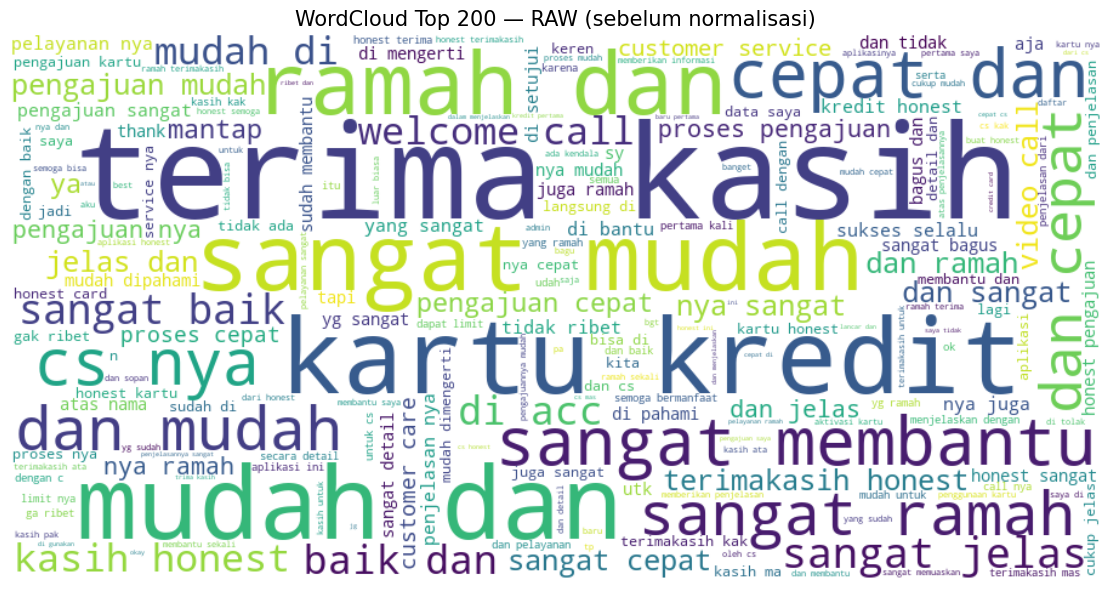

In [103]:
wordcloud_text = ' '.join(all_tokens_raw)
wc = WordCloud(width=900, height=450, background_color='white', max_words=200).generate(wordcloud_text)
plt.figure(figsize=(14, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud Top 200 — RAW (sebelum normalisasi)', fontsize=15)
plt.tight_layout()
plt.show()

---
## 🗣️ Step 7 — Normalisasi Slang

Memetakan kata-kata informal/singkatan ke bentuk baku menggunakan kamus `slang_dict`. Kamus ini disusun berdasarkan observasi Top 200 di Step 6.

**Cara kerja:**
- Setiap token dicek ke `slang_dict`; jika ada, diganti dengan nilai yang sesuai
- Nilai yang mengandung spasi *(multi-word)* akan di-*split* otomatis — contoh: `'makasih'` → `'terima kasih'` → `['terima', 'kasih']`

> **Edit kamus ini** jika ditemukan singkatan baru dari hasil EDA Step 6.

In [104]:
# EDIT: Tambahkan/ubah kamus slang berdasarkan observasi Step 6
# CATATAN:
#  - Multi-word values OK (misal: 'terima kasih') — fungsi normalize akan di-split
#  - Tidak ada self-mapping
slang_dict = {
    # Singkatan & kata informal
    'yg': 'yang', 'dgn': 'dengan', 'utk': 'untuk', 'krn': 'karena',
    'karna': 'karena', 'gk': 'tidak', 'ga': 'tidak', 'gak': 'tidak',
    'ngga': 'tidak', 'nggak': 'tidak', 'tdk': 'tidak', 'gpp': 'tidak',
    'sy': 'saya', 'km': 'kamu', 'kmu': 'kamu',
    'bs': 'bisa', 'bgt': 'banget', 'bngt': 'banget',
    'lg': 'lagi', 'sdh': 'sudah', 'udh': 'sudah', 'udah': 'sudah', 'dah': 'sudah',
    'blm': 'belum', 'blom': 'belum', 'belom': 'belum',  # belom/blom = slang 'belum' (tanpa fix: Sastrawi stem belom -> bom!)
    'jg': 'juga', 'jls': 'jelas',
    'sm': 'sama', 'spy': 'supaya', 'tp': 'tapi',
    'dr': 'dari', 'pd': 'pada', 'dlm': 'dalam',
    'hrs': 'harus', 'msh': 'masih', 'sdg': 'sedang',
    'tyt': 'ternyata', 'knp': 'kenapa', 'gmn': 'gimana',
    'kpn': 'kapan', 'skrg': 'sekarang', 'skr': 'sekarang',
    'dpt': 'dapat', 'dg': 'dengan', 'u': 'untuk',
    'gt': 'begitu', 'gitu': 'begitu', 'spt': 'seperti',
    'jdi': 'jadi', 'jd': 'jadi',
    'klo': 'kalau', 'kalo': 'kalau',
    'dapet': 'dapat', 'nunggu': 'tunggu', 'sampe': 'sampai',
    'trus': 'terus', 'tau': 'tahu',
    'sempet': 'sempat',
    # Ucapan terima kasih -> 'terima kasih' (dua kata, akan di-split)
    'mksh': 'terima kasih', 'makasih': 'terima kasih',
    'thx': 'terima kasih', 'thanks': 'terima kasih',
    'tks': 'terima kasih', 'tq': 'terima kasih',
    'terimakasih': 'terima kasih',  # normalisasi bentuk gabung
    # Slang umum
    'parah': 'buruk', 'lemot': 'lambat', 'susah': 'sulit',
    'recommended': 'rekomendasi', 'recommend': 'rekomendasi',
    'smoga': 'semoga',
}

def normalize_tokens(tokens):
    result = []
    for token in tokens:
        mapped = slang_dict.get(token, token)
        result.extend(mapped.split())  # handle multi-word mappings
    return result

df['tokens_normalized'] = df['tokens_raw'].apply(normalize_tokens)
print('Contoh normalisasi:')
for i in range(3):
    print(f'  RAW       : {df["tokens_raw"].iloc[i]}')
    print(f'  NORMALIZED: {df["tokens_normalized"].iloc[i]}')
    print()


Contoh normalisasi:
  RAW       : ['ini', 'adalah', 'pertama', 'kali', 'saya', 'menggunakan', 'kartu', 'kredit', 'yang', 'katanya', 'cocok', 'buat', 'anak', 'muda', 'nanti', 'saya', 'update', 'pengalaman', 'saya', 'setelah', 'pakai', 'kartu', 'ini', 'terimakasih', 'buat', 'kak', 'rima', 'yang', 'udah', 'membimbing', 'dengan', 'sangat', 'baik']
  NORMALIZED: ['ini', 'adalah', 'pertama', 'kali', 'saya', 'menggunakan', 'kartu', 'kredit', 'yang', 'katanya', 'cocok', 'buat', 'anak', 'muda', 'nanti', 'saya', 'update', 'pengalaman', 'saya', 'setelah', 'pakai', 'kartu', 'ini', 'terima', 'kasih', 'buat', 'kak', 'rima', 'yang', 'sudah', 'membimbing', 'dengan', 'sangat', 'baik']

  RAW       : ['pengajuan', 'berhasil', 'pelayanan', 'utk', 'cs', 'atas', 'nama', 'rio', 'sangat', 'sopan', 'dan', 'penjelasan', 'sangat', 'terperinci', 'terima', 'kasih', 'honest']
  NORMALIZED: ['pengajuan', 'berhasil', 'pelayanan', 'untuk', 'cs', 'atas', 'nama', 'rio', 'sangat', 'sopan', 'dan', 'penjelasan', 'sangat',

---
## 🚫 Step 8 — Stopword Removal Tahap 1 (NLTK Indonesia)

Menghapus *function words* (kata tugas) yang tidak berkontribusi terhadap makna, menggunakan daftar stopword NLTK untuk Bahasa Indonesia (757 kata).

### Sentiment Whitelist

Daftar stopword NLTK Indonesia mencakup beberapa **kata penting untuk analisis sentimen** — seperti `baik`, `bagus`, `cepat`, `sangat` — yang secara teknis adalah kata umum tetapi sangat krusial sebagai sinyal sentimen positif/negatif.

Oleh karena itu, kita terapkan **sentiment whitelist**: kata-kata ini dikeluarkan dari stopword list sebelum filtering dilakukan, sehingga tetap terjaga dalam corpus.

| Kategori | Contoh kata |
|:---------|:------------|
| Sentimen positif | `baik`, `bagus`, `cepat`, `ramah`, `mudah`, `puas`, `mantap` |
| Sentimen negatif | `buruk`, `lambat`, `kecewa`, `gagal`, `tipu`, `masalah` |
| Intensifier | `sangat`, `banget`, `sekali` |

In [105]:
stop_words_id = set(stopwords.words('indonesian'))
print(f'📊 Jumlah stopwords NLTK Indonesia (asli) : {len(stop_words_id)}')

# ── Sentiment Whitelist ───────────────────────────────────────────────
# Kata-kata di bawah ini PENTING untuk analisis sentimen.
# Meski mungkin ada di stopword list NLTK, kita keluarkan agar TIDAK ikut dihapus.
sentiment_whitelist = {
    # Positif
    'baik', 'bagus', 'cepat', 'ramah', 'mudah', 'puas', 'senang',
    'benar', 'lancar', 'aman', 'jelas', 'mantap', 'sukses', 'hebat',
    'terbaik', 'suka', 'percaya', 'bermanfaat', 'terima',
    # Negatif
    'buruk', 'lambat', 'sulit', 'kecewa', 'lama', 'ribet', 'bingung',
    'gagal', 'salah', 'rusak', 'bohong', 'tipu', 'masalah', 'parah',
    # Negasi penting untuk sentimen
    'tidak', 'bukan', 'jangan', 'belum',
    # Intensifier (memperkuat sentiment)
    'sangat', 'banget', 'sekali',
}

stop_words_id = stop_words_id - sentiment_whitelist
print(f'📊 Jumlah stopwords setelah whitelist     : {len(stop_words_id)} (dikurangi {len(sentiment_whitelist)} kata sentiment)')

def remove_stopwords(tokens):
    return [t for t in tokens if t not in stop_words_id and len(t) > 1]

df['tokens_no_sw'] = df['tokens_normalized'].apply(remove_stopwords)
print()
for i in range(3):
    before = df['tokens_normalized'].iloc[i]
    after  = df['tokens_no_sw'].iloc[i]
    print(f'Review {i+1}:')
    print(f'  Sebelum ({len(before):3} token): {before}')
    print(f'  Sesudah ({len(after):3} token): {after}')
    print()

📊 Jumlah stopwords NLTK Indonesia (asli) : 757
📊 Jumlah stopwords setelah whitelist     : 746 (dikurangi 40 kata sentiment)

Review 1:
  Sebelum ( 34 token): ['ini', 'adalah', 'pertama', 'kali', 'saya', 'menggunakan', 'kartu', 'kredit', 'yang', 'katanya', 'cocok', 'buat', 'anak', 'muda', 'nanti', 'saya', 'update', 'pengalaman', 'saya', 'setelah', 'pakai', 'kartu', 'ini', 'terima', 'kasih', 'buat', 'kak', 'rima', 'yang', 'sudah', 'membimbing', 'dengan', 'sangat', 'baik']
  Sesudah ( 17 token): ['kali', 'kartu', 'kredit', 'cocok', 'anak', 'muda', 'update', 'pengalaman', 'pakai', 'kartu', 'terima', 'kasih', 'kak', 'rima', 'membimbing', 'sangat', 'baik']

Review 2:
  Sebelum ( 17 token): ['pengajuan', 'berhasil', 'pelayanan', 'untuk', 'cs', 'atas', 'nama', 'rio', 'sangat', 'sopan', 'dan', 'penjelasan', 'sangat', 'terperinci', 'terima', 'kasih', 'honest']
  Sesudah ( 14 token): ['pengajuan', 'berhasil', 'pelayanan', 'cs', 'nama', 'rio', 'sangat', 'sopan', 'penjelasan', 'sangat', 'terperinci

---
## 🌱 Step 9 — Stemming (Sastrawi)

Melakukan *stemming* morfologi menggunakan **PySastrawi** — stemmer berbasis aturan yang dirancang khusus untuk Bahasa Indonesia. Sastrawi menangani awalan (`me-`, `ber-`, `ter-`, `pe-`, `ke-`) dan akhiran (`-an`, `-kan`, `-i`) sesuai kaidah morfologi Indonesia.

**Contoh hasil stemming:**

| Sebelum | Sesudah |
|:--------|:--------|
| `pengajuan` | `aju` |
| `pelayanan` | `layan` |
| `membimbing` | `bimbing` |
| `penjelasan` | `jelas` |

> **Perhatian:** Proses ini memakan waktu untuk dataset besar (± beberapa menit untuk 38.000+ review).

In [106]:
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stem_tokens(tokens):
    return [stemmer.stem(t) for t in tokens]

# Stemming bisa lama untuk dataset besar — simpan progress
print('🚀 Menjalankan stemming... (bisa beberapa menit)')
df['tokens_stemmed'] = df['tokens_no_sw'].apply(stem_tokens)
print('✅ Stemming selesai')
print()
for i in range(3):
    before = df['tokens_no_sw'].iloc[i]
    after  = df['tokens_stemmed'].iloc[i]
    print(f'Review {i+1}:')
    print(f'  Sebelum ({len(before):3} token): {before}')
    print(f'  Sesudah ({len(after):3} token): {after}')
    print()

🚀 Menjalankan stemming... (bisa beberapa menit)
✅ Stemming selesai

Review 1:
  Sebelum ( 17 token): ['kali', 'kartu', 'kredit', 'cocok', 'anak', 'muda', 'update', 'pengalaman', 'pakai', 'kartu', 'terima', 'kasih', 'kak', 'rima', 'membimbing', 'sangat', 'baik']
  Sesudah ( 17 token): ['kali', 'kartu', 'kredit', 'cocok', 'anak', 'muda', 'update', 'alam', 'pakai', 'kartu', 'terima', 'kasih', 'kak', 'rima', 'bimbing', 'sangat', 'baik']

Review 2:
  Sebelum ( 14 token): ['pengajuan', 'berhasil', 'pelayanan', 'cs', 'nama', 'rio', 'sangat', 'sopan', 'penjelasan', 'sangat', 'terperinci', 'terima', 'kasih', 'honest']
  Sesudah ( 14 token): ['aju', 'hasil', 'layan', 'cs', 'nama', 'rio', 'sangat', 'sopan', 'jelas', 'sangat', 'perinci', 'terima', 'kasih', 'honest']

Review 3:
  Sebelum (  3 token): ['pengajuan', 'cepat', 'aman']
  Sesudah (  3 token): ['aju', 'cepat', 'aman']



---
## 📊 Step 10 — EDA: Top 200 Kata After Cleaning

Observasi kedua setelah normalisasi + stopword removal + stemming. Tujuannya adalah mengidentifikasi **noise yang tersisa** untuk ditangani di Step 11.

| Yang Dicari | Contoh | Aksi |
|:------------|:-------|:-----|
| Nama orang / CS | `ridwan`, `rio`, `azmi` | Tambahkan ke `custom_stopwords_manual` |
| Artifact stemmer | `nya`, `aju`, `moga`, `erti`, `an` | Tambahkan ke `custom_stopwords_manual` |
| Kata filler tanpa sentimen | `ya`, `sih`, `deh`, `ok` | Tambahkan ke `custom_stopwords_manual` |
| Nama aplikasi | `honest`, `honestbank` | Tambahkan ke `custom_stopwords_manual` |

> Setelah mengidentifikasi kata-kata di atas, perbaiki `custom_stopwords_manual` di Step 11, lalu jalankan ulang dari Step 11.

In [107]:
all_tokens_clean = [token for tokens in df['tokens_stemmed'] for token in tokens]
freq_clean = Counter(all_tokens_clean)
top200_clean = pd.DataFrame(freq_clean.most_common(200), columns=['Kata', 'Frekuensi'])
top200_clean.index = top200_clean.index + 1
top200_clean.index.name = 'Rank'

print(f'📊 Total kata unik setelah stemming  : {len(freq_clean):,}')
print(f'📊 Total kemunculan token            : {sum(freq_clean.values()):,}')
print()
print('\n👁️ Top 200 Kata (setelah normalisasi + stopwords + stemming):')
pd.set_option('display.max_rows', None)
display(top200_clean)
pd.reset_option('display.max_rows')

📊 Total kata unik setelah stemming  : 12,618
📊 Total kemunculan token            : 382,123


👁️ Top 200 Kata (setelah normalisasi + stopwords + stemming):


,Kata,Frekuensi
Rank,,
1,kasih,15221
2,sangat,14846
3,terima,14501
4,mudah,12626
5,nya,11603
6,honest,11189
7,jelas,9633
8,aju,9349
9,cepat,8849


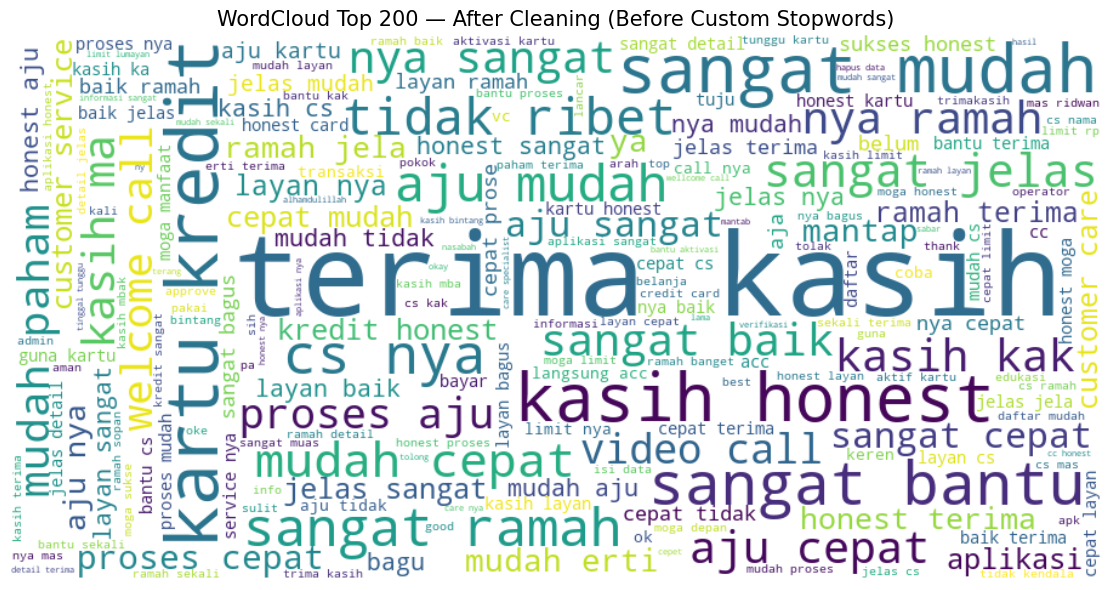

In [108]:
wordcloud_text2 = ' '.join(all_tokens_clean)
wc2 = WordCloud(width=900, height=450, background_color='white', max_words=200).generate(wordcloud_text2)
plt.figure(figsize=(14, 6))
plt.imshow(wc2, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud Top 200 — After Cleaning (Before Custom Stopwords)', fontsize=15)
plt.tight_layout()
plt.show()

---
## ✂️ Step 11 — Custom Stopwords (Tahap 2)

Menghapus noise domain-spesifik yang tidak dapat ditangani oleh stopword list umum. Daftar ini disusun berdasarkan observasi Top 200 di Step 10.

| Kategori | Kata yang dihapus |
|:---------|:------------------|
| Nama CS / agent | `ridwan`, `akbar`, `azmi`, `rio`, `jeremy`, dll. |
| Sapaan / honorifik | `kak`, `mas`, `mba`, `pak`, `bu`, `bang` |
| Nama aplikasi | `honest`, `honestbank` |
| Artifact stemmer | `nya`, `aju`, `moga`, `erti`, `an` |
| Kata filler | `ya`, `iya`, `sih`, `deh`, `dong`, `wah`, `nah` |
| Singkatan netral | `ok`, `oke`, `rp`, `rb`, `jt`, `app`, `hp` |

In [109]:
# Berdasarkan observasi Top 200 di Step 10:
custom_stopwords_manual = {
    # ── Nama CS / orang yang muncul di Top 200 ──
    'ridwan', 'akbar', 'adi', 'kiki', 'azmi', 'romeo', 'rima', 'farhan',
    'maxy', 'fitri', 'afan', 'sony', 'kevin', 'aan', 'rio', 'novi',
    'raden', 'pandu', 'nata', 'lia', 'badal', 'michael', 'ujang', 'saiful',
    'maya', 'jeremy', 'budi', 'dian', 'rini', 'sari',
    # ── Sapaan / honorifik ──
    'ka', 'kak', 'ms', 'mas', 'mba', 'mbak', 'bang', 'bu', 'pak', 'pa', 'bpk',
    # ── Nama aplikasi ──
    'honest', 'honestbank',
    # ── Noise / artifact dari stemmer ──
    'nya', 'aju', 'moga', 'erti', 'an',
    # ── Filler / kata tanpa makna sentimen ──
    'ya', 'iya', 'sih', 'deh', 'dong', 'nih', 'loh', 'lo', 'gue', 'gw',
    'wah', 'nah', 'eh', 'oh', 'ih', 'hm', 'hmm',
    # ── Kata netral / singkatan angka ──
    'ok', 'oke', 'okay', 'rp', 'rb', 'jt', 'cc', 'csnya',
    # ── Generic app words ──
    'aplikasi', 'app', 'hp', 'handphone',
}

def remove_custom_stopwords(tokens):
    return [t for t in tokens if t not in custom_stopwords_manual and len(t) > 1]

df['tokens_final'] = df['tokens_stemmed'].apply(remove_custom_stopwords)
n_before = sum(len(t) for t in df['tokens_stemmed'])
n_after  = sum(len(t) for t in df['tokens_final'])
print(f'🗑️ Token dihapus : {n_before:,} → {n_after:,} (berkurang {n_before-n_after:,})')
print()
for i in range(3):
    print(f'Review {i+1}:')
    print(f'  Sebelum ({len(df["tokens_stemmed"].iloc[i]):3}): {df["tokens_stemmed"].iloc[i]}')
    print(f'  Sesudah ({len(df["tokens_final"].iloc[i]):3}): {df["tokens_final"].iloc[i]}')
    print()

🗑️ Token dihapus : 382,123 → 314,696 (berkurang 67,427)

Review 1:
  Sebelum ( 17): ['kali', 'kartu', 'kredit', 'cocok', 'anak', 'muda', 'update', 'alam', 'pakai', 'kartu', 'terima', 'kasih', 'kak', 'rima', 'bimbing', 'sangat', 'baik']
  Sesudah ( 15): ['kali', 'kartu', 'kredit', 'cocok', 'anak', 'muda', 'update', 'alam', 'pakai', 'kartu', 'terima', 'kasih', 'bimbing', 'sangat', 'baik']

Review 2:
  Sebelum ( 14): ['aju', 'hasil', 'layan', 'cs', 'nama', 'rio', 'sangat', 'sopan', 'jelas', 'sangat', 'perinci', 'terima', 'kasih', 'honest']
  Sesudah ( 11): ['hasil', 'layan', 'cs', 'nama', 'sangat', 'sopan', 'jelas', 'sangat', 'perinci', 'terima', 'kasih']

Review 3:
  Sebelum (  3): ['aju', 'cepat', 'aman']
  Sesudah (  2): ['cepat', 'aman']



### 🔍 Verifikasi: Top 200 Setelah Custom Stopwords

Pastikan nama orang, honorifik, dan noise sudah tidak muncul di jajaran top kata.  
Jika masih ada, tambahkan ke `custom_stopwords_manual` dan jalankan ulang Step 11.

In [110]:
all_tokens_final_check = [token for tokens in df['tokens_final'] for token in tokens]
freq_final_check = Counter(all_tokens_final_check)
top200_final_check = pd.DataFrame(freq_final_check.most_common(200), columns=['Kata', 'Frekuensi'])
top200_final_check.index = top200_final_check.index + 1
top200_final_check.index.name = 'Rank'

print(f'📊 Total kata unik setelah Custom Stopwords : {len(freq_final_check):,}')
print()
print('\n👁️ Top 200 Kata (Setelah Custom Stopwords):')
pd.set_option('display.max_rows', None)
display(top200_final_check)
pd.reset_option('display.max_rows')

📊 Total kata unik setelah Custom Stopwords : 12,544


👁️ Top 200 Kata (Setelah Custom Stopwords):


,Kata,Frekuensi
Rank,,
1,kasih,15221
2,sangat,14846
3,terima,14501
4,mudah,12626
5,jelas,9633
6,cepat,8849
7,ramah,8550
8,kartu,7462
9,tidak,7454


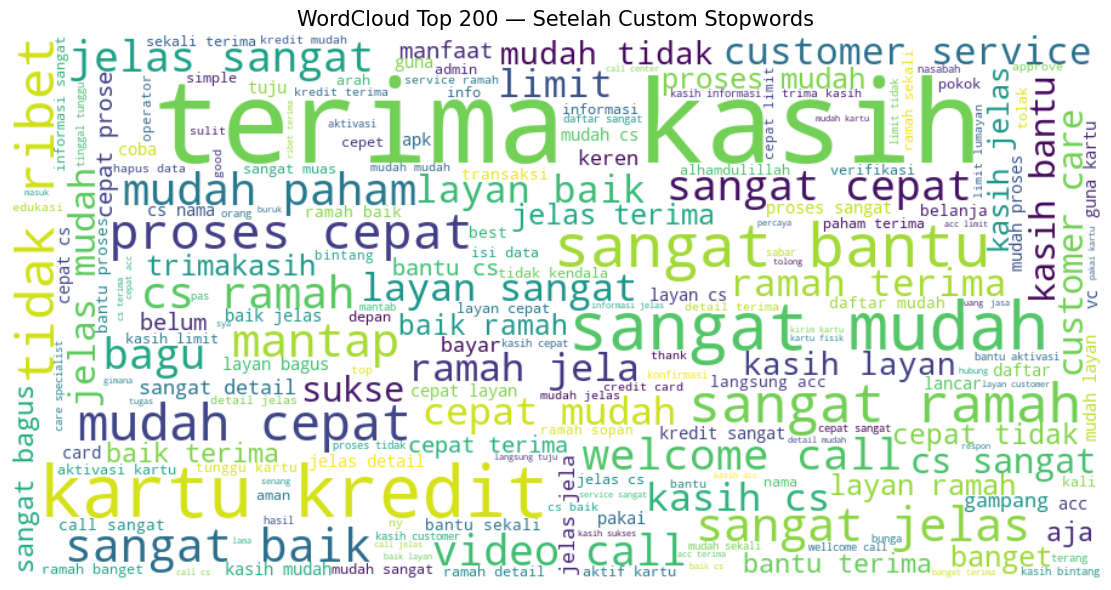

In [111]:
wordcloud_text3 = ' '.join(all_tokens_final_check)
wc3 = WordCloud(width=900, height=450, background_color='white', max_words=200).generate(wordcloud_text3)
plt.figure(figsize=(14, 6))
plt.imshow(wc3, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud Top 200 — Setelah Custom Stopwords', fontsize=15)
plt.tight_layout()
plt.show()

---
## 🗑️ Step 12 — Rare Words Removal

Menghapus kata yang muncul **≤ 3 kali** di seluruh dataset. Kata sangat jarang biasanya merupakan:
- Typo atau salah ketik yang unik
- Nama tempat atau brand yang sangat spesifik
- Token noise yang lolos dari filter sebelumnya

Menghapus kata-kata ini mereduksi ukuran vocabulary secara signifikan tanpa kehilangan informasi sentimen yang bermakna.

In [112]:
all_final = [t for tokens in df['tokens_final'] for t in tokens]
freq_final = Counter(all_final)

# Kata yang muncul <= 3 kali (rare words)
min_freq = 3
rare_words = {w for w, c in freq_final.items() if c <= min_freq}
print(f'📊 Rare words (<= {min_freq}x)         : {len(rare_words):,} kata')

if len(rare_words) == 0:
    print('⚠️ Rare words sudah dihapus sebelumnya. Jalankan dari awal (Restart Kernel & Run All).')
else:
    print()

    # Tampilkan 50 contoh rare words sebelum dihapus
    rare_sample = pd.DataFrame(
        sorted([(w, freq_final[w]) for w in rare_words], key=lambda x: -x[1])[:50],
        columns=['Kata', 'Frekuensi']
    )
    rare_sample.index = rare_sample.index + 1
    rare_sample.index.name = 'No'
    print('\n👁️ 50 contoh rare words (sebelum dihapus):')
    display(rare_sample)

    # Hapus rare words
    def remove_rare(tokens):
        return [t for t in tokens if t not in rare_words]

    df['tokens_final'] = df['tokens_final'].apply(remove_rare)

    # Statistik akhir
    all_final2 = [t for tokens in df['tokens_final'] for t in tokens]
    print(f'\n📊 Total token unik sebelum : {len(freq_final):,}')
    print(f'📊 Total token unik sesudah : {len(set(all_final2)):,}')

📊 Rare words (<= 3x)         : 9,453 kata


👁️ 50 contoh rare words (sebelum dihapus):


,Kata,Frekuensi
No,,
1,ternyta,3
2,perlahan,3
3,dihandle,3
4,ariva,3
5,gunting,3
6,keamananya,3
7,are,3
8,amiiiin,3
9,sadap,3



📊 Total token unik sebelum : 12,544
📊 Total token unik sesudah : 3,091


---
## 💾 Step 13 — Ekspor Data Bersih

Menggabungkan token kembali menjadi string dan mengekspor hasilnya ke `cleandata.csv` di folder **Week 3**.

**Kolom yang diekspor:**

| Kolom | Keterangan |
|:------|:-----------|
| `score` | Rating 1–5 bintang (label sentimen) |
| `content` | Teks asli (untuk referensi dan interpretasi) |
| `text_final` | Teks bersih hasil preprocessing (fitur untuk model) |
| `reviewCreatedVersion` | Versi aplikasi saat review dibuat (jika tersedia) |

 > Review yang menghasilkan `text_final` kosong setelah preprocessing dihapus dari dataset akhir.

In [113]:
# Gabungkan token kembali menjadi kalimat
df['text_final'] = df['tokens_final'].apply(lambda tokens: ' '.join(tokens))

# Sertakan kolom versi jika ada (untuk barchart per versi di bawah)
base_cols = ['score', 'content', 'text_final']
ver_col = next((c for c in ['reviewCreatedVersion', 'appVersion'] if c in df.columns), None)
export_cols = base_cols + ([ver_col] if ver_col else [])

df_export = df[export_cols].copy()
n_before = len(df_export)
df_export = df_export[df_export['text_final'].str.strip() != '']
n_after = len(df_export)

df_export.to_csv('cleandata.csv', index=False)

print('=' * 55)
print('RINGKASAN PREPROCESSING')
print('=' * 55)
print(f'  Review awal (setelah filter bahasa) : {n_before:>7,}')
print(f'  Review kosong setelah preprocessing : {n_before-n_after:>7,}')
print(f'  Review akhir disimpan               : {n_after:>7,}')
print(f'  Persentase tersisa                  : {n_after/n_before*100:.1f}%')
print('=' * 55)
print('✅ Disimpan ke : Week 3/cleandata.csv')
print()

# Tampilkan content & text_final secara lengkap (tidak truncated)
pd.set_option('display.max_colwidth', None)
print(f"\n👁️ Preview 5 baris:")
display(df_export[['content', 'text_final']].head(5))
pd.reset_option('display.max_colwidth')

RINGKASAN PREPROCESSING
  Review awal (setelah filter bahasa) :  39,324
  Review kosong setelah preprocessing :     160
  Review akhir disimpan               :  39,164
  Persentase tersisa                  : 99.6%
✅ Disimpan ke : Week 3/cleandata.csv


👁️ Preview 5 baris:


,content,text_final
0,ini adalah pertama kali saya menggunakan kartu kredit. yang katanya cocok buat anak muda. nanti saya update pengalaman saya setelah pakai kartu ini. terimakasih buat kak rima yang udah membimbing dengan sangat baik,kali kartu kredit cocok anak muda update alam pakai kartu terima kasih bimbing sangat baik
1,"pengajuan berhasil, pelayanan utk CS atas nama Rio sangat sopan dan penjelasan sangat terperinci, terima kasih Honest",hasil layan cs nama sangat sopan jelas sangat perinci terima kasih
2,Pengajuan cepat dan aman..,cepat aman
3,cs Ridwan terbaik,cs baik
4,penjelasan yang baik oleh mba rima,jelas baik


---
## 📊 Visualisasi: Distribusi Rating

Menampilkan distribusi rating ulasan secara keseluruhan dan per versi mayor aplikasi untuk memahami pola sentimen pengguna dari waktu ke waktu.

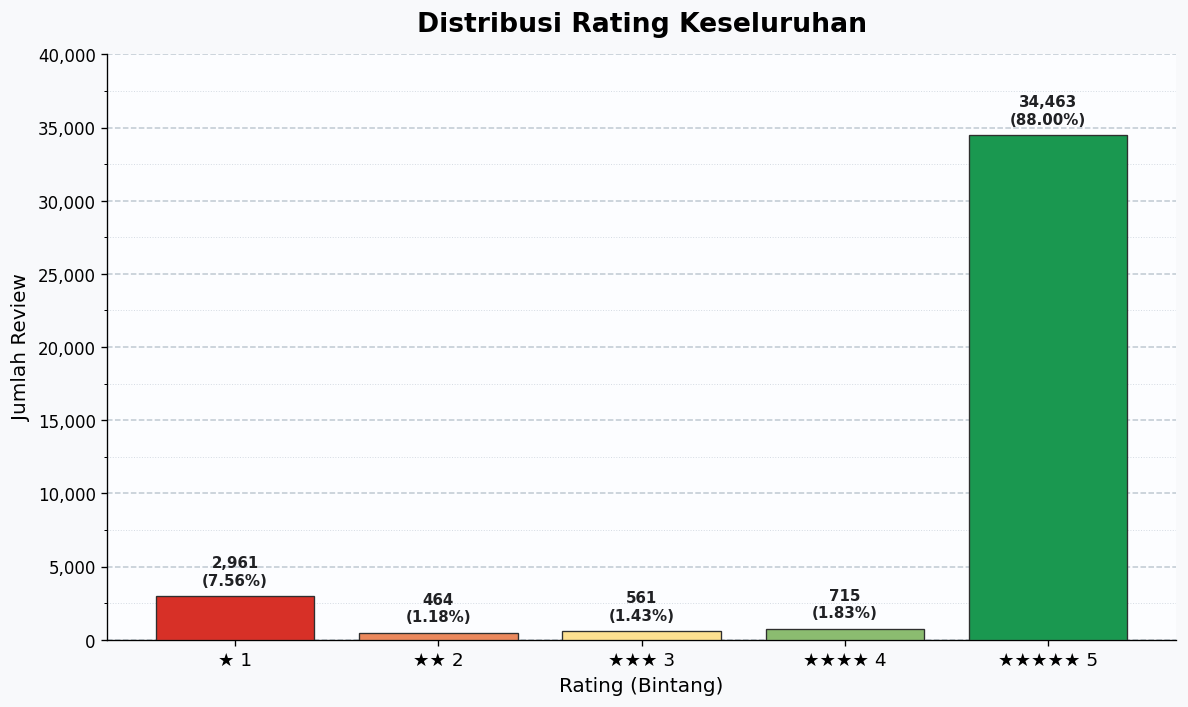

✅ Chart disimpan ke Week 3/rating_distribution.png (enhanced)


In [114]:
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import MultipleLocator, FuncFormatter

# Gradient: Rating 1 (Merah) → Rating 3 (Kuning) → Rating 5 (Hijau)
cmap_rating = LinearSegmentedColormap.from_list('rating', ['#d73027', '#fee090', '#1a9850'])
bar_colors = [cmap_rating(i / 4) for i in range(5)]  # 5 ratings

# ── Plot: Distribusi Rating Keseluruhan ──
rating_counts = df_export['score'].value_counts().sort_index()
total_reviews = rating_counts.sum()

fig, ax = plt.subplots(figsize=(10, 6), dpi=120)
fig.patch.set_facecolor('#f8f9fb')
ax.set_facecolor('#fcfdff')

bars = ax.bar(
    rating_counts.index,
    rating_counts.values,
    color=bar_colors,
    edgecolor='#2f2f2f',
    linewidth=0.8,
    width=0.78,
    zorder=3,
 )

# Format sumbu dan judul
ax.set_title('Distribusi Rating Keseluruhan', fontsize=16, fontweight='bold', pad=14)
ax.set_xlabel('Rating (Bintang)', fontsize=12)
ax.set_ylabel('Jumlah Review', fontsize=12)
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_xticklabels(['★ 1', '★★ 2', '★★★ 3', '★★★★ 4', '★★★★★ 5'], fontsize=11)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))

# Garis bantu: mayor tiap 5000, minor tiap 2500
ax.yaxis.set_major_locator(MultipleLocator(5000))
ax.yaxis.set_minor_locator(MultipleLocator(2500))
ax.grid(which='major', axis='y', linestyle='--', linewidth=0.9, color='#b8c2cc', alpha=0.9, zorder=0)
ax.grid(which='minor', axis='y', linestyle=':', linewidth=0.6, color='#d2d9e1', alpha=0.9, zorder=0)
ax.grid(axis='x', visible=False)

# Tambahkan ruang atas agar label tidak mepet
ymax = int((rating_counts.max() * 1.14) // 5000 * 5000 + 5000)
ax.set_ylim(0, ymax)

# Label nilai + persentase di atas bar
for bar, val in zip(bars, rating_counts.values):
    pct = val / total_reviews * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + ymax * 0.015,
        f'{val:,}\n({pct:.2f}%)',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold',
        color='#202124',
    )

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig('rating_distribution.png', dpi=170, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('✅ Chart disimpan ke Week 3/rating_distribution.png (enhanced)')

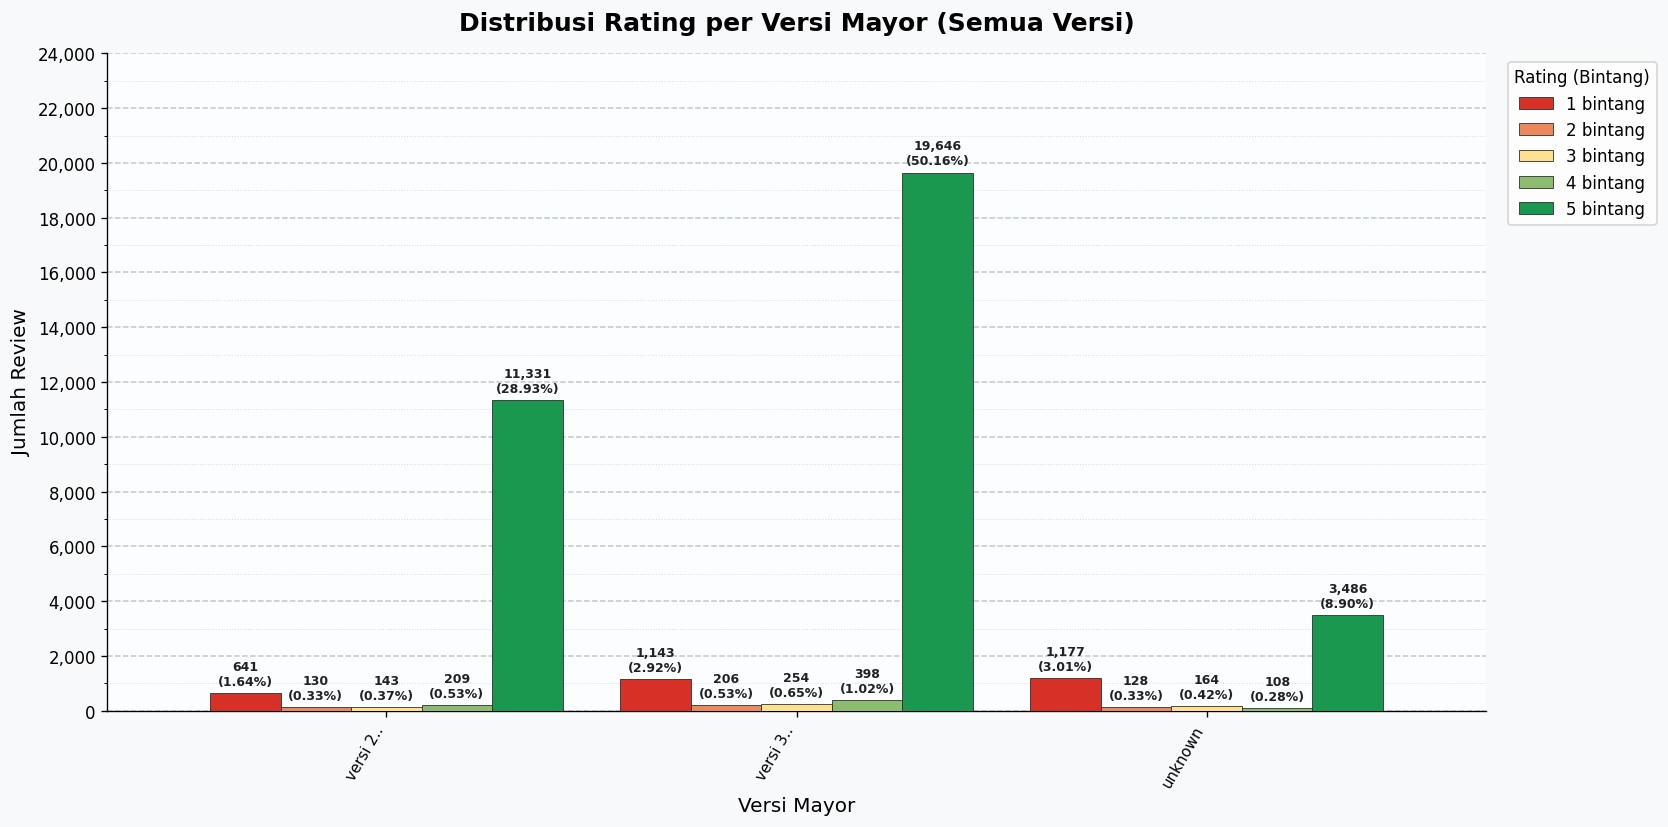

✅ Chart disimpan ke Week 3/rating_distribution_per_version.png (all major versions + labels)


In [115]:
from matplotlib.ticker import MultipleLocator, FuncFormatter

# ── Plot: Distribusi Rating Per Versi Mayor (Semua Versi) ──
ver_col = next((c for c in ['reviewCreatedVersion', 'appVersion'] if c in df_export.columns), None)

if ver_col:
    df_ver = df_export.copy()
    total_reviews = len(df_ver)
    # Ekstrak versi mayor; jika tidak ada angka → 'unknown'
    df_ver['major_version'] = df_ver[ver_col].astype(str).str.extract(r'^(\d+)')[0].fillna('unknown')

    # Ambil SEMUA versi mayor dan urutkan: angka ascending, unknown di akhir
    all_versions = df_ver['major_version'].value_counts().index.tolist()
    numeric_versions = sorted([v for v in all_versions if v != 'unknown'], key=lambda x: int(x))
    versions_sorted = numeric_versions + (['unknown'] if 'unknown' in all_versions else [])

    # Pivot: baris=versi, kolom=rating
    pivot = df_ver.groupby(['major_version', 'score']).size().unstack(fill_value=0)
    pivot = pivot.reindex(versions_sorted).fillna(0).astype(int)

    # Pastikan rating 1..5 selalu tampil meski ada yang tidak muncul
    pivot = pivot.reindex(columns=[1, 2, 3, 4, 5], fill_value=0)

    # Ukuran figure adaptif terhadap jumlah versi
    n_versions = len(versions_sorted)
    fig_width = max(14, n_versions * 0.72)
    fig, ax = plt.subplots(figsize=(fig_width, 7), dpi=120)
    fig.patch.set_facecolor('#f8f9fb')
    ax.set_facecolor('#fcfdff')

    # Bar chart dengan gradient per rating
    pivot_colors = {rating: bar_colors[rating - 1] for rating in pivot.columns}
    pivot.plot(
        kind='bar',
        ax=ax,
        color=[pivot_colors[c] for c in pivot.columns],
        edgecolor='#2f2f2f',
        linewidth=0.5,
        width=0.86,
        zorder=3,
    )

    # Format judul dan sumbu
    ax.set_title('Distribusi Rating per Versi Mayor (Semua Versi)', fontsize=15, fontweight='bold', pad=14)
    ax.set_xlabel('Versi Mayor', fontsize=12)
    ax.set_ylabel('Jumlah Review', fontsize=12)
    ax.set_xticklabels(
        [f'versi {v}..' if v != 'unknown' else 'unknown' for v in versions_sorted],
        rotation=60,
        ha='right',
        fontsize=9,
    )
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))

    # Grid adaptif berdasarkan skala nilai tertinggi
    max_count = int(pivot.values.max()) if pivot.values.size else 0
    if max_count <= 5000:
        major_step = 500
    elif max_count <= 15000:
        major_step = 1000
    elif max_count <= 30000:
        major_step = 2000
    else:
        major_step = 5000
    minor_step = max(1, major_step // 2)

    ymax = int((max_count * 1.12) // major_step * major_step + major_step) if max_count > 0 else major_step
    ax.set_ylim(0, ymax)
    ax.yaxis.set_major_locator(MultipleLocator(major_step))
    ax.yaxis.set_minor_locator(MultipleLocator(minor_step))
    ax.grid(which='major', axis='y', linestyle='--', linewidth=0.9, color='#b8c2cc', alpha=0.9, zorder=0)
    ax.grid(which='minor', axis='y', linestyle=':', linewidth=0.6, color='#d2d9e1', alpha=0.85, zorder=0)
    ax.grid(axis='x', visible=False)

    # Label jumlah + persentase di setiap bar (persentase terhadap total review)
    for patch in ax.patches:
        height = patch.get_height()
        if height <= 0:
            continue
        pct = (height / total_reviews) * 100 if total_reviews > 0 else 0
        ax.text(
            patch.get_x() + patch.get_width() / 2,
            height + ymax * 0.008,
            f'{int(height):,}\n({pct:.2f}%)',
            ha='center',
            va='bottom',
            fontsize=7.5,
            fontweight='bold',
            color='#202124',
            zorder=5,
        )

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    ax.legend(
        title='Rating (Bintang)',
        labels=[f'{r} bintang' for r in pivot.columns],
        bbox_to_anchor=(1.01, 1),
        loc='upper left',
        frameon=True,
    )

    plt.tight_layout()
    plt.savefig('rating_distribution_per_version.png', dpi=170, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()
    print('✅ Chart disimpan ke Week 3/rating_distribution_per_version.png (all major versions + labels)')
else:
    print('⚠️ Kolom versi tidak ditemukan dalam data.')

---
## 📋 Ringkasan Pipeline

| Langkah | Deskripsi Singkat | Dampak |
|:--------|:------------------|:-------|
| Lowercasing | Normalisasi kapitalisasi | Mengurangi duplikasi kata |
| Punctuation Removal | Hapus tanda baca & angka | Membersihkan karakter noise |
| Expand Contractions | Ekspansi singkatan Inggris | Normalisasi ~662 review |
| Tokenization | Split per spasi | ~535K token dari ~39K review |
| Normalisasi Slang | Pemetaan 40+ kata informal | Standarisasi bahasa gaul Indonesia |
| Stopword Removal (NLTK + Whitelist) | 757 kata − 40 kata sentimen | Hapus function words, jaga sinyal sentimen |
| Stemming (Sastrawi) | Reduksi morfologi Indonesia | Vokabulari lebih padat dan konsisten |
| Custom Stopwords | Nama CS, filler, noise domain | Hapus kata domain-spesifik tanpa makna |
| Rare Words Removal | Frekuensi <= 3 | Reduksi vocab dari ~12K -> ~3K kata unik |
| Ekspor | Simpan `cleandata.csv` | Dataset siap untuk pelatihan model sentimen |

---

## 🧠 Analisa Singkat Berdasarkan Output Terbaru

Berdasarkan output terbaru dari `cleandata.csv`, ada tiga temuan utama. Pertama, kualitas hasil preprocessing tetap baik: dataset akhir berisi **39.164 review**, tidak ada `text_final` kosong, dengan rata-rata panjang teks **7,72 kata** dan median **6 kata**. Ini menunjukkan cleaning berhasil mengurangi noise tanpa menghilangkan konteks utama.

Kedua, distribusi label masih **sangat tidak seimbang**. Rating **5 bintang** mendominasi sebanyak **34.463 review (88,00%)**, rating **1 bintang** sebanyak **2.961 review (7,56%)**, sedangkan gabungan rating **2-4** hanya **4,44%**. Karena itu, tahap modeling tetap perlu strategi imbalance handling seperti **stratified split**, **class weighting**, atau **resampling** agar evaluasi lebih adil.

Ketiga, pola distribusi per versi mayor masih konsisten: **versi 3** menjadi kontributor terbesar (**21.647 review**), diikuti **versi 2** (**12.454 review**) dan **`unknown`** (**5.063 review**). Porsi `unknown` ini tetap perlu dipantau karena metadata versi yang tidak lengkap bisa memengaruhi interpretasi tren sentimen antar-rilis.

Secara keseluruhan, dataset hasil preprocessing sudah siap untuk analisis lanjutan, dengan catatan utama bahwa ketimpangan kelas harus dikontrol pada tahap training dan evaluasi model.